# Introduction

This notebook explores the Red Wine Quality dataset from the UCI Machine Learning Repository. The data contains physicochemical properties of red wines and a sensory quality score (0–10). Our goal is to:

Perform exploratory data analysis (EDA) to understand the relationships between features and wine quality.

Build classification models to predict whether a wine is “good” (quality ≥ 7) or “bad”.

Build regression models to predict the actual quality score.

Evaluate models with appropriate metrics and interpret feature importance.

We’ll use Python with pandas, matplotlib, seaborn, scikit‑learn, and XGBoost. Let’s begin!

#  Setup and Data Loading

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, mean_squared_error, 
                             mean_absolute_error, r2_score)
import warnings
warnings.filterwarnings('ignore')

# Set visual style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)



In [2]:
# Load the dataset 
df = pd.read_csv('/kaggle/input/datasets/organizations/uciml/red-wine-quality-cortez-et-al-2009/winequality-red.csv')

# Display first few rows
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


#  Data Overview and Basic Statistics

In [3]:
# Check data shape, types, missing values
print(f"Dataset shape: {df.shape}\n")
print("Data types:\n", df.dtypes)
print("\nMissing values per column:\n", df.isnull().sum())

# Summary statistics
print("\nSummary statistics:")
df.describe()

Dataset shape: (1599, 12)

Data types:
 fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

Missing values per column:
 fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Summary statistics:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


#  Exploratory Data Analysis (EDA)

## Distribution of Wine Quality

Unique quality values: [5 6 7 4 8 3]


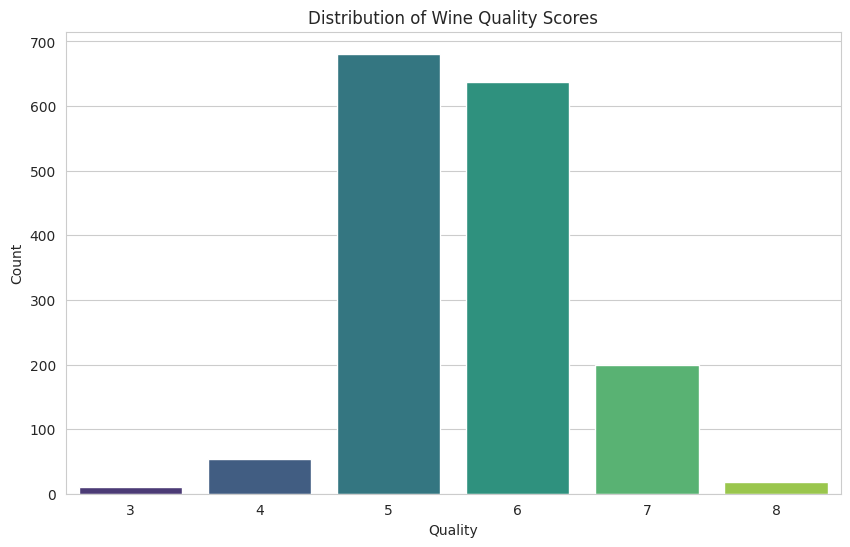

Quality distribution (%):
 quality
3     0.63
4     3.31
5    42.59
6    39.90
7    12.45
8     1.13
Name: count, dtype: float64


In [4]:
# Quality is an integer from 3 to 8 (no 0–10 range in this red wine subset)
print("Unique quality values:", df['quality'].unique())

# Count plot of quality
plt.figure(figsize=(10,6))
sns.countplot(x='quality', data=df, palette='viridis')
plt.title('Distribution of Wine Quality Scores')
plt.xlabel('Quality')
plt.ylabel('Count')
plt.show()

# Show percentages
quality_counts = df['quality'].value_counts().sort_index()
quality_percent = quality_counts / len(df) * 100
print("Quality distribution (%):\n", quality_percent.round(2))

## Create Binary Target for Classification

In [5]:
# Define threshold
threshold = 6.5  # quality > 6.5 -> good (i.e., quality >= 7)
df['is_good'] = (df['quality'] > threshold).astype(int)

# Check balance
print("Class distribution:\n", df['is_good'].value_counts())
print("\nPercentage good wines:", df['is_good'].mean() * 100, "%")

Class distribution:
 is_good
0    1382
1     217
Name: count, dtype: int64

Percentage good wines: 13.570981863664791 %


##  Univariate Analysis of Features

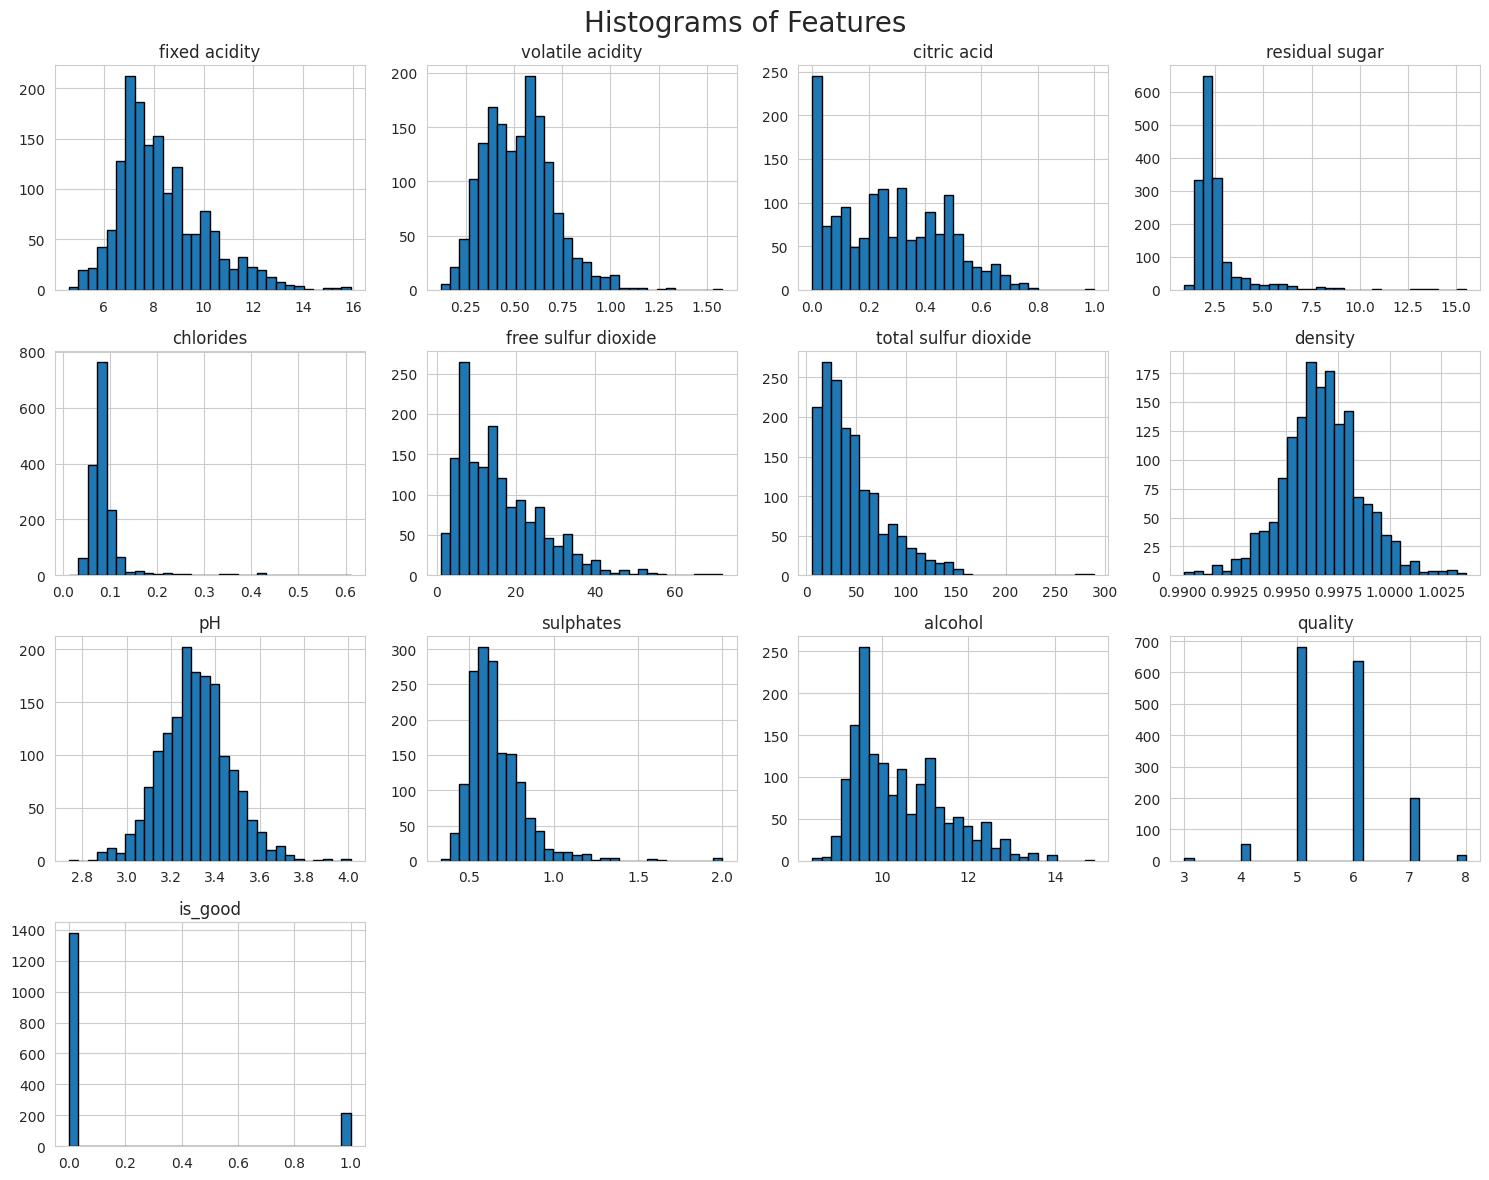

In [6]:
# Plot histograms for all features
df.hist(bins=30, figsize=(15,12), edgecolor='black')
plt.suptitle('Histograms of Features', size=20)
plt.tight_layout()
plt.show()

## Boxplots by Quality (Continuous Target)

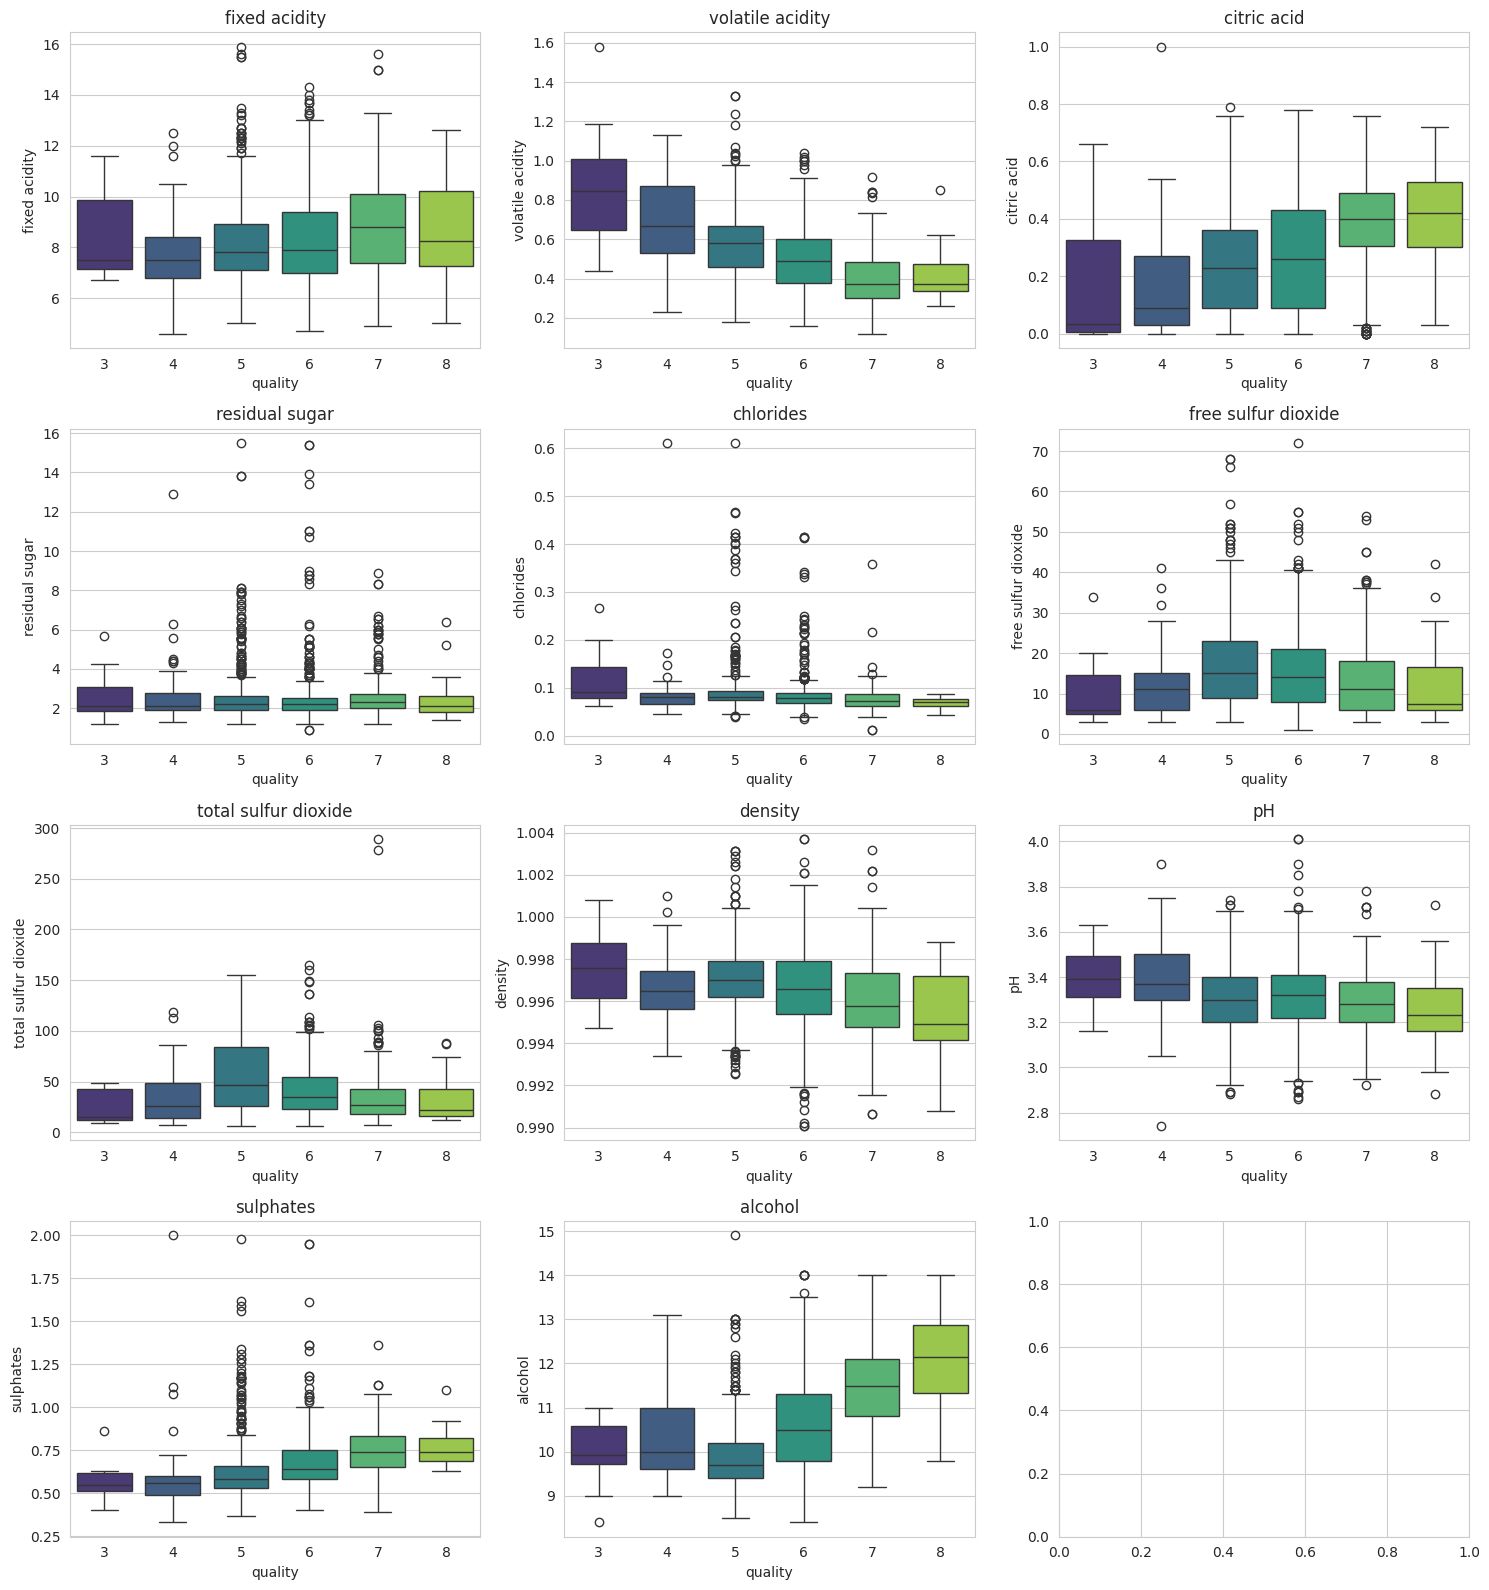

In [7]:
# Boxplots of features grouped by quality
fig, axes = plt.subplots(4, 3, figsize=(15, 16))
axes = axes.flatten()
for i, col in enumerate(df.columns[:-2]):  # exclude 'quality' and 'is_good'
    sns.boxplot(x='quality', y=col, data=df, ax=axes[i], palette='viridis')
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

##  Correlation Analysis

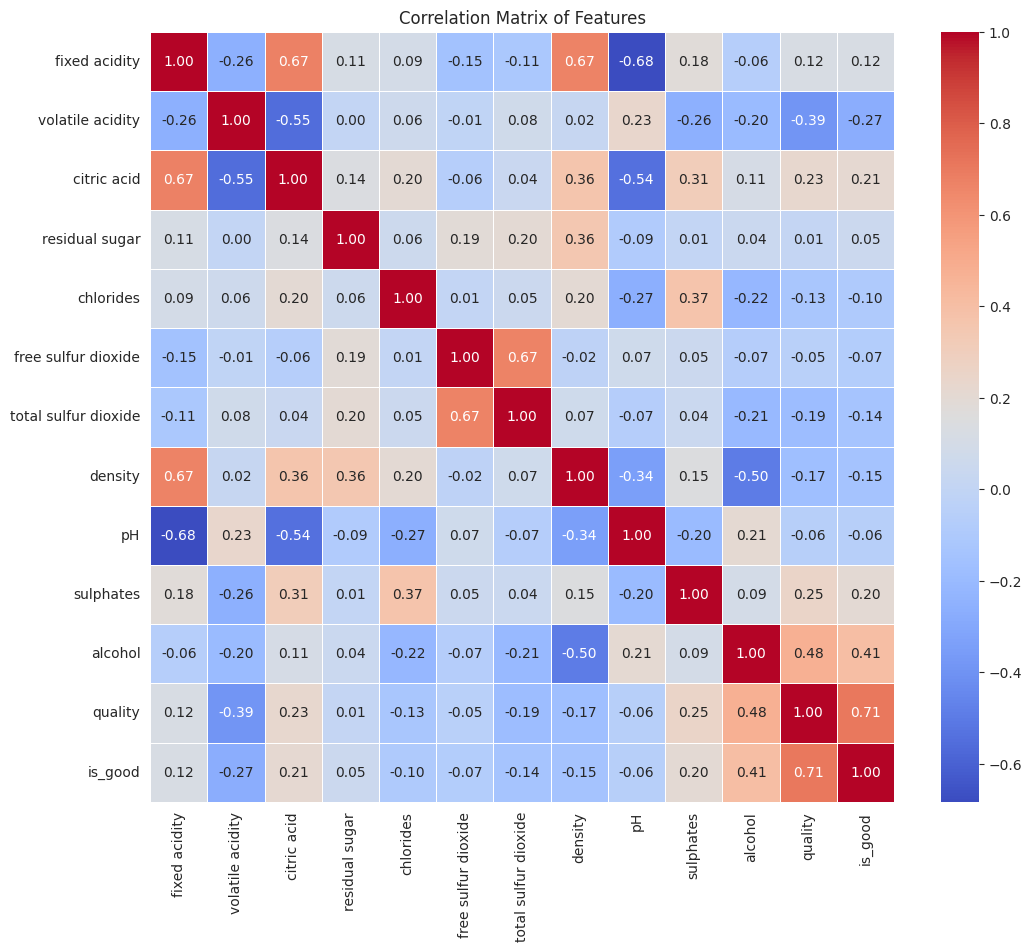

Correlations with quality:
 quality                 1.000000
is_good                 0.710196
alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64


In [8]:
# Correlation matrix
corr = df.corr()

# Heatmap
plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Features')
plt.show()

# Correlations with quality
print("Correlations with quality:\n", corr['quality'].sort_values(ascending=False))

## Pairplot of Selected Features

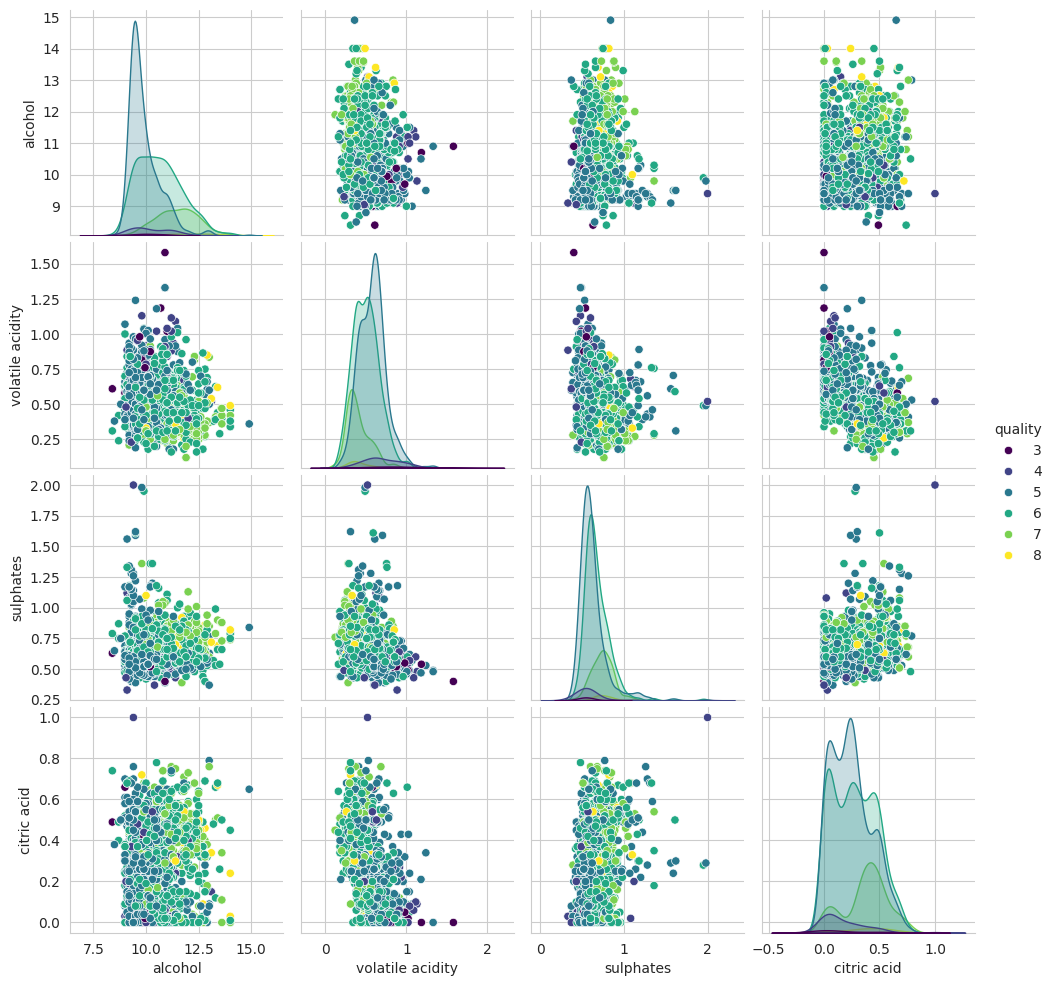

In [9]:
# Select a subset of features for pairplot
selected = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid', 'quality']
sns.pairplot(df[selected], hue='quality', palette='viridis', diag_kind='kde')
plt.show()

#  Preprocessing for Modeling

In [10]:
# Define feature set (exclude 'quality' and 'is_good')
X = df.drop(['quality', 'is_good'], axis=1)
y_class = df['is_good']      # classification target
y_reg = df['quality']        # regression target

# Train-test split (stratified for classification)
X_train, X_test, y_train_class, y_test_class = train_test_split(
    X, y_class, test_size=0.3, random_state=42, stratify=y_class
)

# For regression we can use the same split (but no need to stratify)
_, _, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.3, random_state=42, stratify=y_class
)   # Note: we reuse the same indices; better to keep consistency

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

##  Classification Modeling (Good vs. Bad)

###  Logistic Regression


In [11]:
# Train logistic regression
lr = LogisticRegression(random_state=42, class_weight='balanced')  # handle imbalance
lr.fit(X_train_scaled, y_train_class)

# Predictions
y_pred_lr = lr.predict(X_test_scaled)
y_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]

# Metrics
print("Logistic Regression Performance")
print("Accuracy:", accuracy_score(y_test_class, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test_class, y_proba_lr))
print("\nClassification Report:\n", classification_report(y_test_class, y_pred_lr))

Logistic Regression Performance
Accuracy: 0.8041666666666667
ROC-AUC: 0.8831881371640408

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.80      0.88       415
           1       0.39      0.82      0.53        65

    accuracy                           0.80       480
   macro avg       0.68      0.81      0.70       480
weighted avg       0.89      0.80      0.83       480



### Decision Tree

In [12]:
# Decision tree (tuned for depth to avoid overfitting)
dt = DecisionTreeClassifier(random_state=42, max_depth=5, class_weight='balanced')
dt.fit(X_train, y_train_class)  # no scaling needed

y_pred_dt = dt.predict(X_test)
y_proba_dt = dt.predict_proba(X_test)[:, 1]

print("Decision Tree Performance")
print("Accuracy:", accuracy_score(y_test_class, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test_class, y_proba_dt))
print("\nClassification Report:\n", classification_report(y_test_class, y_pred_dt))

Decision Tree Performance
Accuracy: 0.8166666666666667
ROC-AUC: 0.8535310472659869

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.83      0.89       415
           1       0.40      0.72      0.52        65

    accuracy                           0.82       480
   macro avg       0.68      0.78      0.70       480
weighted avg       0.88      0.82      0.84       480



### Random Forest

In [13]:
# Random forest with default parameters
rf = RandomForestClassifier(random_state=42, class_weight='balanced')
rf.fit(X_train, y_train_class)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest Performance")
print("Accuracy:", accuracy_score(y_test_class, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test_class, y_proba_rf))
print("\nClassification Report:\n", classification_report(y_test_class, y_pred_rf))

Random Forest Performance
Accuracy: 0.925
ROC-AUC: 0.9374791473586654

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.99      0.96       415
           1       0.89      0.51      0.65        65

    accuracy                           0.93       480
   macro avg       0.91      0.75      0.80       480
weighted avg       0.92      0.93      0.92       480



### XGBoost

In [14]:
# XGBoost classifier (scale_pos_weight to handle imbalance)
scale_pos_weight = (len(y_train_class) - y_train_class.sum()) / y_train_class.sum()
xgb = XGBClassifier(random_state=42, scale_pos_weight=scale_pos_weight, eval_metric='logloss')
xgb.fit(X_train, y_train_class)

y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

print("XGBoost Performance")
print("Accuracy:", accuracy_score(y_test_class, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test_class, y_proba_xgb))
print("\nClassification Report:\n", classification_report(y_test_class, y_pred_xgb))

XGBoost Performance
Accuracy: 0.93125
ROC-AUC: 0.9558480074142726

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.97      0.96       415
           1       0.80      0.66      0.72        65

    accuracy                           0.93       480
   macro avg       0.87      0.82      0.84       480
weighted avg       0.93      0.93      0.93       480



### ROC Curves Comparison

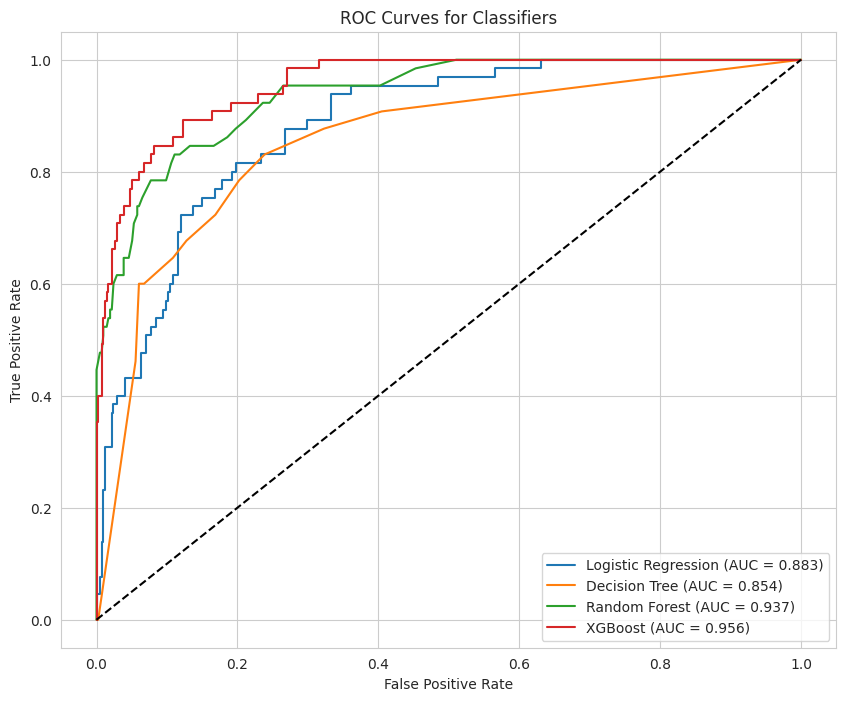

In [15]:
# Plot ROC curves for all models
plt.figure(figsize=(10,8))
models = [lr, dt, rf, xgb]
names = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost']

for model, name in zip(models, names):
    if name == 'Logistic Regression':
        proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_class, proba)
    auc = roc_auc_score(y_test_class, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Classifiers')
plt.legend()
plt.show()

###  Hyperparameter Tuning (Random Forest)

In [16]:
# Grid search for Random Forest
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'class_weight': ['balanced']
}

rf_tune = RandomForestClassifier(random_state=42)
grid = GridSearchCV(rf_tune, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid.fit(X_train, y_train_class)

print("Best parameters:", grid.best_params_)
print("Best cross-val AUC:", grid.best_score_)

best_rf = grid.best_estimator_
y_proba_best = best_rf.predict_proba(X_test)[:, 1]
print("Test AUC:", roc_auc_score(y_test_class, y_proba_best))

Best parameters: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
Best cross-val AUC: 0.8898417566840298
Test AUC: 0.9380722891566264


### Feature Importance (Random Forest)

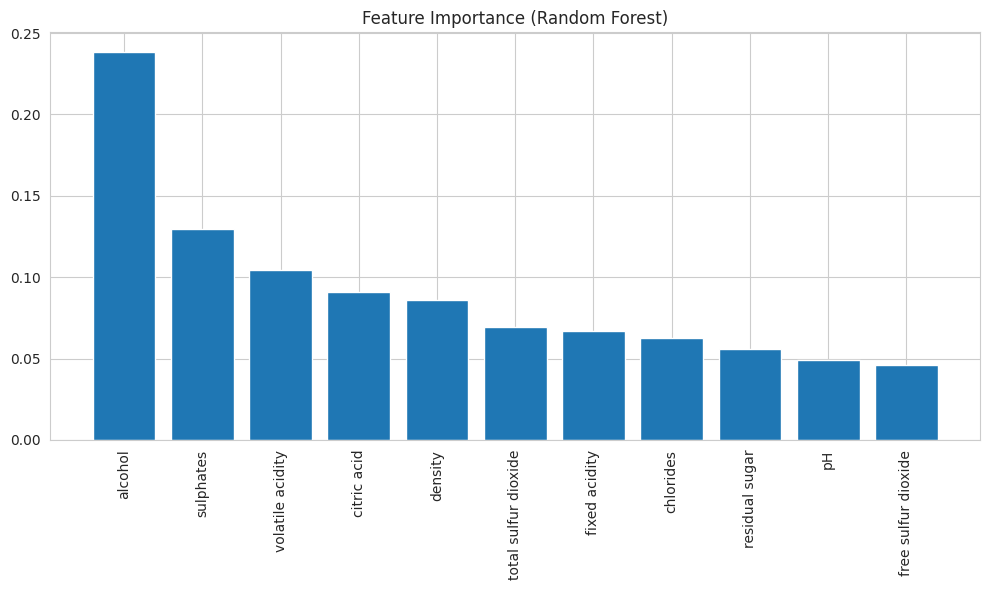

In [17]:
# Feature importance from the best Random Forest
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]
features = X.columns

plt.figure(figsize=(10,6))
plt.title('Feature Importance (Random Forest)')
plt.bar(range(len(importances)), importances[indices], align='center')
plt.xticks(range(len(importances)), [features[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()

# Regression Modeling (Predict Quality Score)

In [18]:
# Scale features for linear regression
X_train_scaled_reg = scaler.fit_transform(X_train)
X_test_scaled_reg = scaler.transform(X_test)

# Linear Regression
lr_reg = LinearRegression()
lr_reg.fit(X_train_scaled_reg, y_train_reg)
y_pred_lr = lr_reg.predict(X_test_scaled_reg)

print("Linear Regression")
print("RMSE:", np.sqrt(mean_squared_error(y_test_reg, y_pred_lr)))
print("MAE:", mean_absolute_error(y_test_reg, y_pred_lr))
print("R²:", r2_score(y_test_reg, y_pred_lr))

# Decision Tree Regressor
dt_reg = DecisionTreeRegressor(random_state=42, max_depth=5)
dt_reg.fit(X_train, y_train_reg)
y_pred_dt = dt_reg.predict(X_test)

print("\nDecision Tree Regressor")
print("RMSE:", np.sqrt(mean_squared_error(y_test_reg, y_pred_dt)))
print("MAE:", mean_absolute_error(y_test_reg, y_pred_dt))
print("R²:", r2_score(y_test_reg, y_pred_dt))

# Random Forest Regressor
rf_reg = RandomForestRegressor(random_state=42, n_estimators=200)
rf_reg.fit(X_train, y_train_reg)
y_pred_rf = rf_reg.predict(X_test)

print("\nRandom Forest Regressor")
print("RMSE:", np.sqrt(mean_squared_error(y_test_reg, y_pred_rf)))
print("MAE:", mean_absolute_error(y_test_reg, y_pred_rf))
print("R²:", r2_score(y_test_reg, y_pred_rf))

# XGBoost Regressor
xgb_reg = XGBRegressor(random_state=42, n_estimators=200)
xgb_reg.fit(X_train, y_train_reg)
y_pred_xgb = xgb_reg.predict(X_test)

print("\nXGBoost Regressor")
print("RMSE:", np.sqrt(mean_squared_error(y_test_reg, y_pred_xgb)))
print("MAE:", mean_absolute_error(y_test_reg, y_pred_xgb))
print("R²:", r2_score(y_test_reg, y_pred_xgb))

Linear Regression
RMSE: 0.6518565402378094
MAE: 0.5018913586349848
R²: 0.38704308778976915

Decision Tree Regressor
RMSE: 0.6822515458594693
MAE: 0.5151464820921526
R²: 0.3285480350547697

Random Forest Regressor
RMSE: 0.5807152109683369
MAE: 0.4146979166666666
R²: 0.5135342194729494

XGBoost Regressor
RMSE: 0.6149466674443925
MAE: 0.40594273805618286
R²: 0.454492449760437


## Residual Analysis 

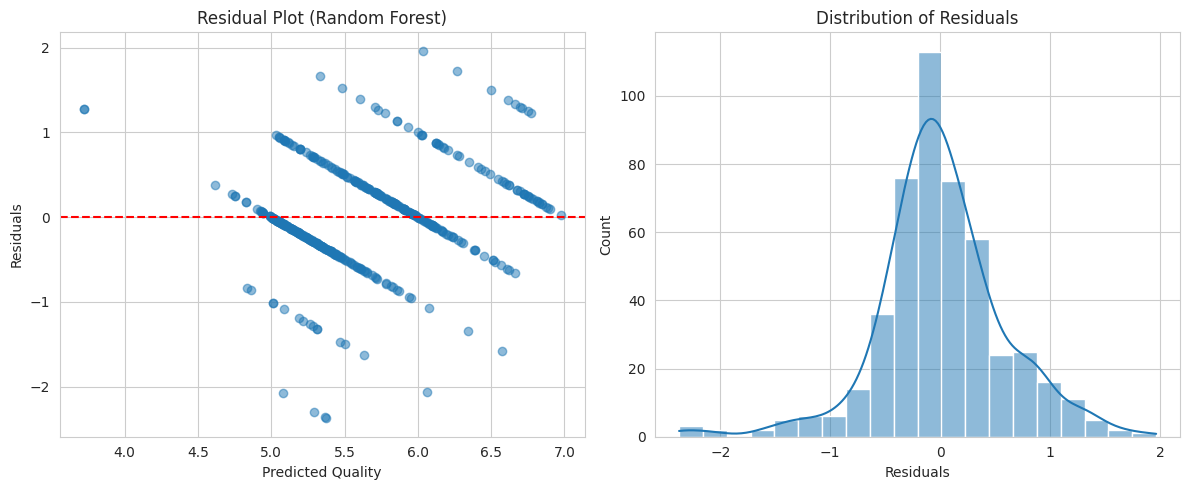

In [19]:
# Residuals for Random Forest regressor
residuals = y_test_reg - y_pred_rf

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(y_pred_rf, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Quality')
plt.ylabel('Residuals')
plt.title('Residual Plot (Random Forest)')

plt.subplot(1,2,2)
sns.histplot(residuals, kde=True, bins=20)
plt.xlabel('Residuals')
plt.title('Distribution of Residuals')
plt.tight_layout()
plt.show()

In [20]:
# Re-run necessary imports and data loading (if starting fresh)
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import joblib   # for saving/loading models


# Features (excluding quality and is_good)
X = df.drop(['quality', 'is_good'], axis=1)
y = df['is_good']

# Split into train/test (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Train the best model (tuned Random Forest from previous grid search)
best_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=2,
    class_weight='balanced',
    random_state=42
)
best_rf.fit(X_train, y_train)

# Evaluate on test set (optional)
from sklearn.metrics import roc_auc_score
y_proba = best_rf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_proba)
print(f"Test AUC: {auc:.4f}")

Test AUC: 0.9352


# Save the Model

In [21]:
# Save the model to a pickle file
joblib.dump(best_rf, '/kaggle/working/best_rf_model.pkl')
print("Model saved to /kaggle/working/best_rf_model.pkl")

Model saved to /kaggle/working/best_rf_model.pkl


# Load the Model and Make Predictions

In [22]:
# Load the saved model
loaded_model = joblib.load('/kaggle/working/best_rf_model.pkl')

# Example: predict on the test set we kept
y_pred = loaded_model.predict(X_test)
y_proba = loaded_model.predict_proba(X_test)[:, 1]

# Show some predictions
print("First 10 predictions (class):", y_pred[:10])
print("First 10 probabilities:", y_proba[:10])

# To predict on completely new data (e.g., a single wine sample)
new_sample = pd.DataFrame({
    'fixed acidity': [7.4],
    'volatile acidity': [0.7],
    'citric acid': [0.0],
    'residual sugar': [1.9],
    'chlorides': [0.076],
    'free sulfur dioxide': [11.0],
    'total sulfur dioxide': [34.0],
    'density': [0.9978],
    'pH': [3.51],
    'sulphates': [0.56],
    'alcohol': [9.4]
})

# Predict class and probability
pred_class = loaded_model.predict(new_sample)[0]
pred_proba = loaded_model.predict_proba(new_sample)[0, 1]
print(f"Predicted class: {'Good' if pred_class == 1 else 'Bad'}")
print(f"Probability of being good: {pred_proba:.4f}")

First 10 predictions (class): [0 0 0 0 0 0 0 0 0 0]
First 10 probabilities: [0.07075283 0.08314682 0.02       0.         0.02       0.0423806
 0.01475106 0.         0.13378895 0.065     ]
Predicted class: Bad
Probability of being good: 0.0078


In [23]:
print("Thanks you so much ")

Thanks you so much 
